In [1]:
%matplotlib inline
%reload_ext autoreload
%autoreload 2

In [2]:
import sys

sys.path.append('../scripts')

In [3]:
import numpy as np
import scanpy as sc
import anndata as ad
import pandas as pd
import os
import seaborn as sns
import matplotlib.pyplot as plt

from tqdm import tqdm
from sklearn.model_selection import train_test_split

from cellina import CellinaModel
from utils import set_seed
from train_loo import preprocess_adata

/data/ddimitrov/software/miniforge3/envs/cellina/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
/data/ddimitrov/software/miniforge3/envs/cellina/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_excel from `anndata` is deprecated. Import anndata.io.read_excel instead.
  warnings.warn(msg, FutureWarning)
/data/ddimitrov/software/miniforge3/envs/cellina/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_hdf from `anndata` is deprecated. Import anndata.io.read_hdf instead.
  warnings.warn(msg, FutureWarning)
/data/ddimitrov/software/miniforge3/envs/cellina/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)
/data/ddimitrov/software/miniforge3/envs/cellina/l

In [4]:
plt.rcParams['font.family'] = 'monospace'
plt.rcParams['font.size'] = 16
plt.rcParams['figure.dpi'] = 50


In [5]:
import cellina
cellina.__version__

'0.7.1'

# Get dataset

In [6]:
set_seed(0)

In [7]:
slide_id = 'crc_210'

In [8]:
data_path = f"/data/a330d/datasets/crc/raw_zenodo/{slide_id}.h5ad"
adata = sc.read(data_path)
adata.obs_names_make_unique()

In [9]:
adata = preprocess_adata(adata, n_neighbors=200)

/data/ddimitrov/software/miniforge3/envs/cellina/lib/python3.10/site-packages/scanpy/preprocessing/_simple.py:165: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs["n_counts"] = number


In [10]:
adata

AnnData object with n_obs × n_vars = 552241 × 2000
    obs: 'fov', 'Area', 'AspectRatio', 'CenterX_local_px', 'CenterY_local_px', 'Width', 'Height', 'Mean.PanCK', 'Max.PanCK', 'Mean.CD68_CK8_18', 'Max.CD68_CK8_18', 'Mean.CD298_B2M', 'Max.CD298_B2M', 'Mean.CD45', 'Max.CD45', 'Mean.DAPI', 'Max.DAPI', 'cell_id', 'Dash', 'ISH.concentration', 'Panel', 'Run_Tissue_name', 'Run_name', 'assay_type', 'dualfiles', 'tissue', 'version', 'slide_ID', 'CenterX_global_px', 'CenterY_global_px', 'cell_ID', 'unassignedTranscripts', 'median_RNA', 'RNA_quantile_0.75', 'RNA_quantile_0.8', 'RNA_quantile_0.85', 'RNA_quantile_0.9', 'RNA_quantile_0.95', 'RNA_quantile_0.99', 'nCount_RNA', 'nFeature_RNA', 'median_negprobes', 'negprobes_quantile_0.75', 'negprobes_quantile_0.8', 'negprobes_quantile_0.85', 'negprobes_quantile_0.9', 'negprobes_quantile_0.95', 'negprobes_quantile_0.99', 'nCount_negprobes', 'nFeature_negprobes', 'median_falsecode', 'falsecode_quantile_0.75', 'falsecode_quantile_0.8', 'falsecode_quantile

In [11]:
labels_key = 'coarse_type'
domains_key = 'typ_clean'
batch_key = 'sid'

In [12]:
fig_save_path = "../figures/application"

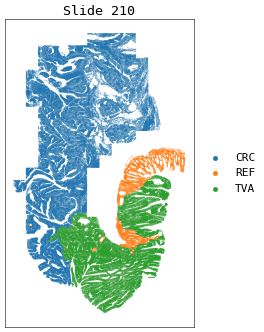

In [13]:
fig, ax = plt.subplots(figsize=(8, 8))  # width x height in inches

sc.pl.spatial(
    adata,
    color=domains_key,
    ax=ax,
    spot_size=100,
    title=f"Slide 210",
    show=False,
)
# Remove x and y axis labels
ax.set_xlabel('')
ax.set_ylabel('')

# Optionally, remove ticks too
ax.set_xticks([])
ax.set_yticks([])
plt.show()

fig.savefig(f"{fig_save_path}/{slide_id}slide.png", bbox_inches='tight')

## Data splits

In [14]:
split = "random"

# Get holdout indices
if split == "random":
    fraction = 0.1
    n_cells = adata.n_obs
    n_holdout = int(n_cells * fraction)

    # Randomly choose cells
    test_idx = np.random.choice(n_cells, n_holdout, replace=False)

elif split == "ood":
    holdout_ct = "Fibroblast"
    is_tumor_region  = adata.obs[domains_key].str.contains("CRC", regex=True)
    is_holdout_ct = adata.obs[labels_key] == holdout_ct

    # Combine for test set
    test_mask = (is_tumor_region) & (is_holdout_ct)
    test_idx = np.where(test_mask)[0]
else:
    raise ValueError(f"Unknown split: {split}")

# Get train/val indices
all_idx = np.arange(adata.n_obs)
trainval_idx = np.setdiff1d(all_idx, test_idx)

In [15]:
# Set 'is_holdout' to False by default, then True for selected cells
adata.obs['is_holdout'] = False
adata.obs.iloc[test_idx, adata.obs.columns.get_loc('is_holdout')] = True

In [16]:
validation_size = 0.1
train_idx, val_idx = train_test_split(
    trainval_idx,
    test_size=validation_size,
    random_state=0,
    shuffle=True,
)

# Train

In [17]:
model_base_path = f"data/cellina-reproducibility/application/{slide_id}"

In [18]:
from scvi.train._callbacks import SaveCheckpoint, EarlyStopping

model_args = {
    'adata': adata,
    'n_latent': 64,
    'n_layers': 3,
    'use_observed_lib_size': True,
    'condition_on_intrinsic': False,
    'gene_likelihood': 'nb',
    'classifier_lambda': 1.,
    'discriminator_lambda': 1.,
    }
train_args = {'max_epochs': 100,
              'batch_size': 4096,
              'check_val_every_n_epoch': 1,
              'early_stopping': True,
              'devices': [0],
              'datasplitter_kwargs': {
                  "external_indexing": [train_idx, val_idx, test_idx],
                  },
              'enable_checkpointing':True,
              'callbacks': [
                  SaveCheckpoint(
                      monitor='vae_loss_validation',
                      dirpath=f"{model_base_path}",
                      load_best_on_end=True,
                      ),
                  EarlyStopping(
                      monitor="vae_loss_validation",
                      patience=5,
                      mode="min",
                    ),
                ],
    }

plan_kwargs = {
    'lr': 1e-3,
    'normalize_losses': True
    }

In [19]:
CellinaModel.setup_anndata(adata,
                           batch_key=batch_key,
                           labels_key=labels_key, 
                           domains_key=domains_key, 
                           spatial_obsm_key="spatial_x",
                           layer='counts')

INFO     Generating sequential column names                                                                        


/data/ddimitrov/software/miniforge3/envs/cellina/lib/python3.10/site-packages/scvi/data/fields/_layer_field.py:115: UserWarning: Training will be faster when sparse matrix is formatted as CSR. It is safe to cast before model initialization.
  _verify_and_correct_data_format(adata, self.attr_name, self.attr_key)


In [20]:
model = CellinaModel(
    **model_args, 
)
model.train(
    **train_args,
    plan_kwargs=plan_kwargs
)

INFO     cellina: The Cellina model has been initialized with adversarial domain forgetting                        


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
You are using a CUDA device ('NVIDIA GeForce RTX 4090') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
/data/ddimitrov/software/miniforge3/envs/cellina/lib/python3.10/site-packages/lightning/pytorch/callbacks/model_checkpoint.py:654: Checkpoint directory /data/ddimitrov/repos/cellina-reproducibility/notebooks/data/cellina-reproducibility/application/crc_210 exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
/data/ddimitrov/software/miniforge3/envs/cellina/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:424: The 'train_dataloader' does not have many workers which 

Training:   0%|          | 0/100 [00:00<?, ?it/s]

INFO     File                                                                                                      
         /data/ddimitrov/repos/cellina-reproducibility/notebooks/data/cellina-reproducibility/application/crc_210/e
         poch=26-step=5720-vae_loss_validation=309.9802551269531/model.pt already downloaded                       


/data/ddimitrov/software/miniforge3/envs/cellina/lib/python3.10/site-packages/scvi/model/base/_save_load.py:76: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model = torch.l

# Inference and clustering

In [21]:
checkpoint_name = os.listdir(f"{model_base_path}")[0]
model = CellinaModel.load(
    f"{model_base_path}/{checkpoint_name}",
    adata=adata,
)

Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.


INFO     File                                                                                                      
         data/cellina-reproducibility/application/crc_210/epoch=16-step=3520-vae_loss_validation=311.038330078125/m
         odel.pt already downloaded                                                                                


/data/ddimitrov/software/miniforge3/envs/cellina/lib/python3.10/site-packages/scvi/model/base/_save_load.py:76: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model = torch.l

INFO     cellina: The Cellina model has been initialized with adversarial domain forgetting                        


In [22]:
adata.obsm['cellina_basal'] = model.get_latent_representation(adata=adata, latent_key='z', batch_size=4096)
adata.obsm['cellina_spatial'] = model.get_latent_representation(adata=adata, latent_key='s', batch_size=4096)
# adata.obsm['cellina_latent'] = model.get_latent_representation(adata=adata, batch_size=4096)

### Latent visualization

In [23]:
x = 0.5  # fraction of cells to keep (e.g., 10%)

n_cells = adata.n_obs
n_subsample = int(n_cells * x)

# Randomly choose cell indices
np.random.seed(42)  # for reproducibility
subsample_idx = np.random.choice(n_cells, n_subsample, replace=False)

# Create the subsampled AnnData
adata_sub = adata[subsample_idx].copy()

In [24]:
sc.pp.neighbors(adata_sub, use_rep='cellina_basal')
sc.tl.umap(adata_sub)

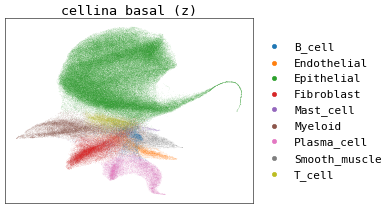

In [25]:
ax = sc.pl.umap(adata_sub, color=[labels_key], wspace=0.3, show=False, title="cellina basal (z)")
# Remove x and y axis labels
ax.set_xlabel('')
ax.set_ylabel('')

# Optionally, remove ticks too
ax.set_xticks([])
ax.set_yticks([])

fig = ax.figure
plt.show()

fig.savefig(f"{fig_save_path}/crc_210_umap_basal_ct.png", bbox_inches='tight')

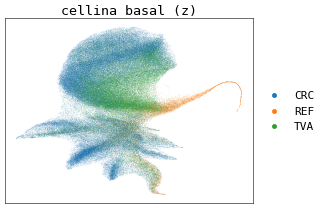

In [26]:
ax = sc.pl.umap(adata_sub, color=[domains_key], wspace=0.3, show=False, title="cellina basal (z)")
# Remove x and y axis labels
ax.set_xlabel('')
ax.set_ylabel('')

# Optionally, remove ticks too
ax.set_xticks([])
ax.set_yticks([])

fig = ax.figure
plt.show()

fig.savefig(f"{fig_save_path}/{slide_id}_umap_basal_niche.png", bbox_inches='tight')

In [27]:
sc.pp.neighbors(adata_sub, use_rep='cellina_spatial')
sc.tl.umap(adata_sub)

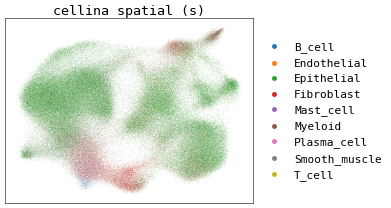

In [28]:
ax = sc.pl.umap(adata_sub, color=[labels_key], wspace=0.3, show=False, title="cellina spatial (s)")
# Remove x and y axis labels
ax.set_xlabel('')
ax.set_ylabel('')

# Optionally, remove ticks too
ax.set_xticks([])
ax.set_yticks([])

fig = ax.figure
plt.show()

fig.savefig(f"{fig_save_path}/{slide_id}_umap_spatial_ct.png", bbox_inches='tight')

In [29]:
palette = {
    # Control
    'REF': '#E69F00',

    # CRC
    'CRC': "#0075D5",

    # TVA
    'TVA': "#00B221",
}

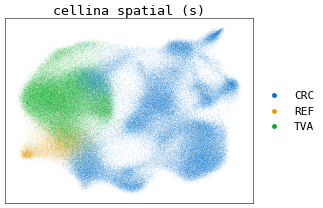

In [30]:
ax = sc.pl.umap(adata_sub, color=[domains_key], wspace=0.3, show=False, title="cellina spatial (s)", palette=palette)
# Remove x and y axis labels
ax.set_xlabel('')
ax.set_ylabel('')

# Optionally, remove ticks too
ax.set_xticks([])
ax.set_yticks([])

fig = ax.figure
plt.show()

fig.savefig(f"{fig_save_path}/{slide_id}_umap_spatial_niche.png", bbox_inches='tight')

## Hotspot clusters

In [31]:
import pandas as pd
import decoupler as dc
import hotspot

from plotting import plot_custom_umap

In [32]:
adata_crc = adata[adata.obs[domains_key].str.contains('CRC')].copy()

In [33]:
hs = hotspot.Hotspot(
    adata_crc,
    layer_key="counts",
    model='danb',
    latent_obsm_key="cellina_spatial",
    umi_counts_obs_key="nCount_RNA"
)

hs.create_knn_graph(
    weighted_graph=False, n_neighbors=30,
)

In [34]:
hs_results = hs.compute_autocorrelations(jobs=24)

100%|██████████| 2000/2000 [00:09<00:00, 215.88it/s]


In [35]:
# Select the genes with significant lineage autocorrelation
top_k = 1200
hs_genes = hs_results.loc[hs_results.FDR < 0.05].head(top_k).index

In [36]:
# Compute pair-wise local correlations between these genes
load_lcz = False
base_dir = f'results/analysis/{slide_id}'
lcz_path = f'{base_dir}/hotspot_lcz_crc.csv'

if load_lcz:
    lcz = pd.read_csv(lcz_path, index_col=0)
    hs.local_correlation_z = lcz
else:
    lcz = hs.compute_local_correlations(hs_genes, jobs=24)
    os.makedirs(base_dir, exist_ok=True)
    lcz.to_csv(lcz_path)

Computing pair-wise local correlation on 1200 features...


100%|██████████| 719400/719400 [12:41<00:00, 944.74it/s]


In [37]:
modules = hs.create_modules(
    min_gene_threshold=100, core_only=True, fdr_threshold=0.05
)

In [38]:
module_scores = hs.calculate_module_scores()

module_scores.head()

Computing scores for 4 modules...


  0%|          | 0/4 [00:00<?, ?it/s]

100%|██████████| 4/4 [00:46<00:00, 11.66s/it]


,1,2,3,4
c_1_1_1,-1.686645,0.534287,7.485766,-0.572624
c_1_1_2,-1.801062,1.447656,7.331687,-1.212035
c_1_1_3,-1.701486,2.023189,8.093203,-1.060070
c_1_1_4,-0.862436,4.077380,5.961052,-0.335745
c_1_1_5,-1.503948,1.351945,7.677480,-1.252290


In [39]:
module_cols = []
for c in module_scores.columns:
    key = f"Module {c}"
    adata_crc.obs[key] = module_scores[c]
    module_cols.append(key)

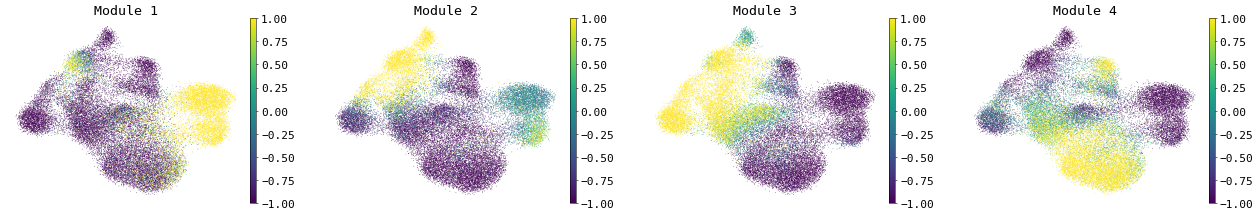

In [40]:
plot_custom_umap(
    adata_crc, subsample=0.1, use_rep='cellina_spatial', color=module_cols,frameon=False, vmin=-1, vmax=1, wspace=0.2
)

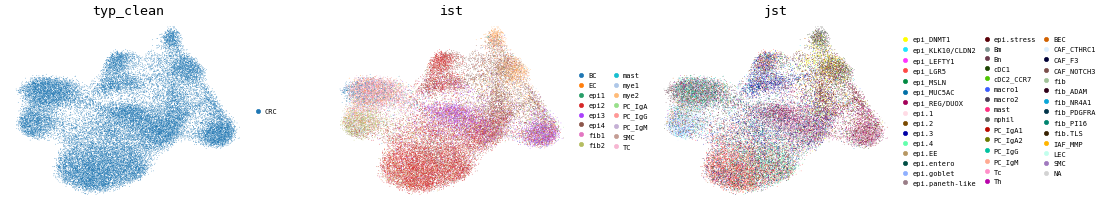

In [41]:
plot_custom_umap(
    adata_crc, subsample=0.1, use_rep='cellina_spatial', color=['typ_clean', 'ist', 'jst'], frameon=False, vmin=-1, vmax=1, wspace=0.2
)

In [42]:
module_scores_epi = module_scores.loc[adata_crc.obs_names]

In [43]:
adata_crc.obsm['module_scores'] = module_scores_epi.values

In [44]:
top_modules = module_scores.idxmax(axis=1)

# Add to adata.obs
adata_crc.obs["top_module"] = top_modules.astype(str)
adata_crc.obs["top_module"] = adata_crc.obs["top_module"].astype("category")

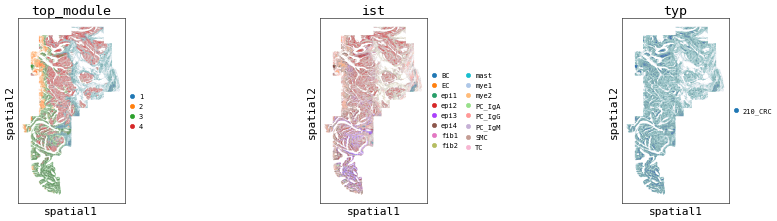

In [45]:
# Plot
sc.pl.spatial(
    adata_crc,
    color=["top_module", "ist", "typ"],
    palette=None,
    spot_size=50,
    show=True
)

In [46]:
# top module to f{CRC{}}
adata_crc.obs['microenvironment'] = adata_crc.obs['top_module'].apply(lambda x: f"CRC{x}")

In [47]:
adata_crc.obs['microenvironment'].value_counts()

microenvironment
CRC4    124781
CRC3     97862
CRC1     81291
CRC2     27454
Name: count, dtype: int64

### Remap

In [48]:
typ_map = adata_crc.obs['microenvironment'].astype(str).reindex(adata_sub.obs_names)  # NaN for non-CRC cells

adata_sub.obs['microenvironment'] = pd.Categorical(
    typ_map.fillna(adata_sub.obs['typ'].astype(str))
)

typ_map = adata_crc.obs['microenvironment'].astype(str).reindex(adata.obs_names)  # NaN for non-CRC cells
adata.obs['microenvironment'] = pd.Categorical(
    typ_map.fillna(adata.obs['typ'].astype(str))
)
    

In [49]:
adata.obs['microenvironment'].value_counts()

microenvironment
210_TVA    185092
CRC4       124781
CRC3        97862
CRC1        81291
210_REF     35761
CRC2        27454
Name: count, dtype: int64

/tmp/ipykernel_3849743/333694513.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  celltype_microenv_counts = adata.obs.groupby([labels_key, 'microenvironment']).size().reset_index(name='count')


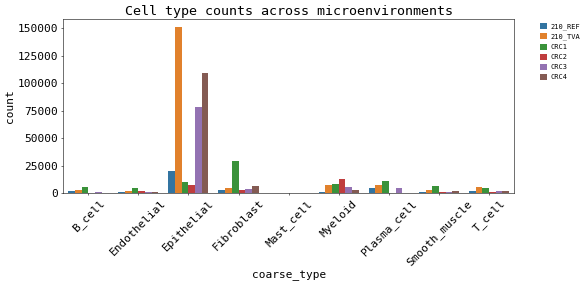

In [50]:
# Plot how many cells of each microenvironment are present in each cell type
celltype_microenv_counts = adata.obs.groupby([labels_key, 'microenvironment']).size().reset_index(name='count')
plt.figure(figsize=(12, 6))
sns.barplot(data=celltype_microenv_counts, x=labels_key, y='count', hue='microenvironment')
plt.xticks(rotation=45)
plt.title("Cell type counts across microenvironments")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Counterfactuals - CRC_global vs. CRC_microenv

In [51]:
celltypes = ['Endothelial', 'Epithelial', 'Fibroblast', 'Myeloid', 'T_cell']
microenvironments = [m for m in adata.obs['microenvironment'].unique() if 'CRC' in m]
results = {k: adata[adata.obs[labels_key] == k] for k in celltypes}

In [52]:
print(microenvironments)

['CRC3', 'CRC2', 'CRC4', 'CRC1']


In [53]:
for ct in tqdm(celltypes, desc=f"Cell types"):
    # Control set is same - only target changes (either crc_all or microenv labels)
    is_tumor_region = adata.obs[domains_key].astype(str).str.contains('CRC', regex=True)
    is_celltype = adata.obs[labels_key].astype(str) == ct
    
    mask_control = ~is_tumor_region & is_celltype
    # mask_control = adata.obs[domains_key].astype(str).str.contains('REF', regex=True) & is_celltype # NOTE: changed from ~CRC to REF
    
    idx_control = np.where(mask_control.values)[0]

    # 1. Compute counterfactuals for global crc
    mask_target = is_tumor_region
    #mask_target = is_tumor_region & is_celltype
    idx_target = np.where(mask_target.values)[0]
    args = {
                "adata": adata,
                "indices": idx_control,
                "neighbour_indices": idx_target,
                "batch_size": 4096,
                "seed": 0,
            }
    results[ct].obsm['recon_x'] = model.get_normalized_expression(adata=results[ct], batch_size=4096, library_size=1e4)
    results[ct].uns[f'counterfactual_x_global'] = model.get_counterfactual_expression(**args, library_size=1e4)
    results[ct].uns[f'counterfactual_latents_global'] = model.get_counterfactual_latents(**args, latent_key='shifted')

    # 2. Loop over microenvironments
    for microenv in tqdm(microenvironments, desc=f"Microenvironments"):
        is_in_microenv = adata.obs['microenvironment'].astype(str).str.contains(microenv, regex=True)
        mask_target = is_in_microenv
        #mask_target = is_in_microenv & is_celltype
        idx_target = np.where(mask_target.values)[0]
        args["neighbour_indices"] = idx_target
        results[ct].uns[f'counterfactual_x_{microenv}'] = model.get_counterfactual_expression(**args, library_size=1e4)
        results[ct].uns[f'counterfactual_latents_{microenv}'] = model.get_counterfactual_latents(**args, latent_key='shifted')

Cell types:   0%|          | 0/5 [00:00<?, ?it/s]

INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             


/data/ddimitrov/software/miniforge3/envs/cellina/lib/python3.10/site-packages/scvi/data/fields/_layer_field.py:115: UserWarning: Training will be faster when sparse matrix is formatted as CSR. It is safe to cast before model initialization.
  _verify_and_correct_data_format(adata, self.attr_name, self.attr_key)


INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        


/data/ddimitrov/software/miniforge3/envs/cellina/lib/python3.10/site-packages/scvi/data/fields/_layer_field.py:115: UserWarning: Training will be faster when sparse matrix is formatted as CSR. It is safe to cast before model initialization.
  _verify_and_correct_data_format(adata, self.attr_name, self.attr_key)


...

/data/ddimitrov/software/miniforge3/envs/cellina/lib/python3.10/site-packages/scvi/data/fields/_layer_field.py:115: UserWarning: Training will be faster when sparse matrix is formatted as CSR. It is safe to cast before model initialization.
  _verify_and_correct_data_format(adata, self.attr_name, self.attr_key)


INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        


/data/ddimitrov/software/miniforge3/envs/cellina/lib/python3.10/site-packages/scvi/data/fields/_layer_field.py:115: UserWarning: Training will be faster when sparse matrix is formatted as CSR. It is safe to cast before model initialization.
  _verify_and_correct_data_format(adata, self.attr_name, self.attr_key)


INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        


/data/ddimitrov/software/miniforge3/envs/cellina/lib/python3.10/site-packages/scvi/data/fields/_layer_field.py:115: UserWarning: Training will be faster when sparse matrix is formatted as CSR. It is safe to cast before model initialization.
  _verify_and_correct_data_format(adata, self.attr_name, self.attr_key)
Cell types: 100%|██████████| 5/5 [01:00<00:00, 12.05s/it]


In [54]:
from scipy.stats import pearsonr, spearmanr
from counterfactual_analysis import safe_log2_fold_change

def _normalize_counts(counts, counts_per_k=1e4, eps=1e-8):
    return counts / (counts.sum(axis=1, keepdims=True) + eps) * counts_per_k


def compute_correlations(control, target, counterfactual, normalize_counts=True, deg=200):
    if normalize_counts:
        control = _normalize_counts(control)
        target = _normalize_counts(target)
        counterfactual = _normalize_counts(counterfactual)

    mean_control = np.nanmean(control, axis=0)
    mean_target = np.nanmean(target, axis=0)
    mean_cf = np.nanmean(counterfactual, axis=0)

    # compute log2 fold changes
    gt_vec = safe_log2_fold_change(mean_target, mean_control)
    cf_vec = safe_log2_fold_change(mean_cf, mean_control)

    deg_scores = np.abs(gt_vec)
    top_features = np.argsort(-deg_scores)[:deg]
    pear, _ = pearsonr(gt_vec[top_features], cf_vec[top_features])
    spear, _ = spearmanr(gt_vec[top_features], cf_vec[top_features])
    """
    # Plot scatterplot of gt vs cf log fold changes - highlight top features in a different color
    import matplotlib.pyplot as plt
    plt.scatter(gt_vec, cf_vec)
    plt.xlabel('Ground Truth Log2 Fold Change')
    plt.ylabel('Counterfactual Log2 Fold Change')
    plt.title('GT vs CF Log2 Fold Change')
    
    # highlight top features in a different color
    plt.scatter(gt_vec[top_features], cf_vec[top_features], color='red')
    plt.show()
    """
    return float(pear), float(spear)

In [55]:
summary = []
deg = 200

for ct, dataset in tqdm(results.items(), desc="Computing correlations"):
    is_tumor_region = adata.obs[domains_key].astype(str).str.contains('CRC', regex=True)
    mask_control = ~dataset.obs[domains_key].astype(str).str.contains('CRC', regex=True)
    # mask_control = dataset.obs[domains_key].astype(str).str.contains('REF', regex=True) # NOTE: change from ~CRC to REF?

    control = dataset.layers['counts'].todense()[mask_control]
    control = np.asarray(control)
    
    is_ct = dataset.obs[labels_key].astype(str) == ct
    #mask_target = is_tumor_region & is_ct
    mask_target = is_tumor_region
    target = adata.layers['counts'].todense()[mask_target]
    target = np.asarray(target)

    counterfactual = dataset.uns['counterfactual_x_global']
    pear_global, spear_global = compute_correlations(control, target, counterfactual, deg=deg)

    summary.append({
        "cell_type": ct,
        "label": "CRC_global",
        "pearson": np.round(pear_global, 4),
        "spearman": np.round(spear_global, 4)
    })

    for microenv in tqdm(microenvironments, desc="Microenvironments"):
        is_in_microenv = adata.obs['microenvironment'].astype(str).str.contains(microenv, regex=True)
        
        #mask_target = is_in_microenv & is_ct
        mask_target = is_in_microenv
        target = adata.layers['counts'].todense()[mask_target]

        target = np.asarray(target)
        counterfactual = dataset.uns[f'counterfactual_x_{microenv}']
        pear_microenv, spear_microenv = compute_correlations(control, target, counterfactual, deg=deg)
        summary.append({
            "cell_type": ct,
            "label": microenv,
            "pearson": np.round(pear_microenv, 4),
            "spearman": np.round(spear_microenv, 4)
        })

Computing correlations:   0%|          | 0/5 [00:00<?, ?it/s]

Computing correlations: 100%|██████████| 5/5 [02:09<00:00, 26.00s/it]


In [56]:
summary_df = pd.DataFrame(summary)

In [57]:
# Save df
summary_df.to_csv(f"../results/microenvironments_{slide_id}.csv", index=False)

# Dumbbell plots

In [58]:
# load df
summary_df = pd.read_csv(f"../results/microenvironments_{slide_id}.csv")

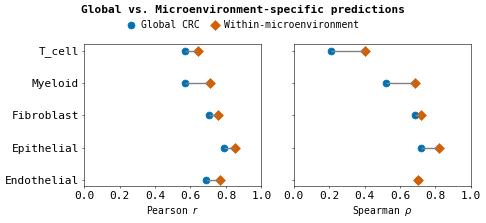

In [59]:
# Prepare data for plotting
plot_data = []
for corr_type in ["pearson","spearman"]:
    tmp = summary_df.copy()
    # Global value
    global_vals = tmp[tmp['label'] == 'CRC_global'].set_index('cell_type')[corr_type]
    # Mean of all others
    mean_others = tmp[tmp['label'] != 'CRC_global'].groupby('cell_type')[corr_type].mean()
    plot_data.append((global_vals, mean_others))

cell_types = summary_df['cell_type'].unique()

# Colorblind-friendly palette
colors = {
    'CRC_global': '#0072B2',      # blue
    'mean_others': '#D55E00'      # orange/red
}

# Monospace font
plt.rcParams['font.family'] = 'monospace'

# Plot
fig, axes = plt.subplots(1, 2, figsize=(10, 5), sharey=True)

for ax, (global_vals, mean_others), title in zip(
    axes, 
    plot_data, 
    [r"Pearson $r$", r"Spearman $\rho$"]
):
    y_pos = np.arange(len(cell_types))
    
    # Dumbbell lines
    ax.hlines(y=y_pos, xmin=mean_others.values, xmax=global_vals.values, color='gray', alpha=1, linewidth=2)
    
    # Scatter points with different shapes
    ax.scatter(global_vals.values, y_pos, color=colors['CRC_global'], s=100, marker='o', label='Global CRC')
    ax.scatter(mean_others.values, y_pos, color=colors['mean_others'], s=100, marker='D', label='Within-microenvironment')
    
    # Y-axis labels
    ax.set_yticks(y_pos)
    ax.set_yticklabels(cell_types)
    #ax.set_xticklabels(ax.get_xticks(), fontsize=10)
    
    # X-axis
    ax.set_xlim(0, 1)
    ax.set_xlabel(title, fontsize=14)

# Overall figure title
fig.suptitle("Global vs. Microenvironment-specific predictions", fontsize=16, fontweight='bold', y=0.9)


# Get legend handles
handles, labels = axes[0].get_legend_handles_labels()

# Place legend BELOW the title, centered, horizontal
fig.legend(
    handles, labels,
    loc='upper center',
    bbox_to_anchor=(0.5, 0.86),  # just below suptitle
    ncol=2,                      # horizontal layout
    frameon=False,
    fontsize=14,                  # increase text size
    markerscale=1.0
)
# Adjust subplots to make room for legend on far right
fig.subplots_adjust(top=0.88)  # shrink axes to leave 20% for legend

plt.tight_layout(rect=[0, 0, 1, 0.88])
plt.savefig(f"{fig_save_path}/dumbbell_{slide_id}.svg", bbox_inches='tight')
plt.show()

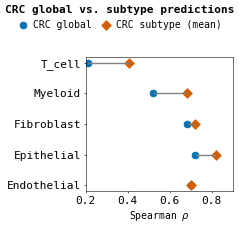

In [60]:
tmp = summary_df.copy()

global_vals = tmp[tmp['label'] == 'CRC_global'].set_index('cell_type')['spearman']
mean_others = tmp[tmp['label'] != 'CRC_global'].groupby('cell_type')['spearman'].mean()

cell_types = summary_df['cell_type'].unique()

# Colorblind-friendly palette
colors = {
    'CRC_global': '#0072B2',
    'mean_others': '#D55E00'
}

plt.rcParams['font.family'] = 'monospace'

fig, ax = plt.subplots(1, 1, figsize=(5, 5))

y_pos = np.arange(len(cell_types))

# Dumbbell lines
ax.hlines(
    y=y_pos,
    xmin=mean_others.values,
    xmax=global_vals.values,
    color='gray',
    linewidth=2
)

# Points
ax.scatter(global_vals.values, y_pos,
           color=colors['CRC_global'], s=100, marker='o', label='CRC global')

ax.scatter(mean_others.values, y_pos,
           color=colors['mean_others'], s=100, marker='D', label='CRC subtype (mean)')

# Y-axis
ax.set_yticks(y_pos)
ax.set_yticklabels(cell_types)

# X-axis (UPDATED RANGE)
ax.set_xlim(0.2, 0.9)
ax.set_xlabel(r"Spearman $\rho$", fontsize=14)

# Title
fig.suptitle(
    "CRC global vs. subtype predictions",
    fontsize=16,
    fontweight='bold',
    y=0.92
)

# Legend
handles, labels = ax.get_legend_handles_labels()
fig.legend(
    handles, labels,
    loc='upper center',
    bbox_to_anchor=(0.5, 0.88),
    ncol=2,
    frameon=False,
    fontsize=14
)

# Layout
fig.subplots_adjust(top=0.82)
plt.tight_layout(rect=[0, 0, 1, 0.85])
plt.savefig(f"{fig_save_path}/dumbbell_spearman_{slide_id}.svg", bbox_inches='tight')
plt.show()

In [61]:
# Read files in a loop, concatenate into a single dataframe, and plot distribution of pearson and spearman correlations across cell types for global vs microenv predictions
import glob

results_path = "../results"
all_files = glob.glob(f"{results_path}/microenvironments_*.csv")
dfs = []
for file in all_files:
    df = pd.read_csv(file)
    df['slide_id'] = file.split("_")[-1].split(".")[0]  # extract slide_id from filename
    dfs.append(df)
dumbbell_df = pd.concat(dfs, ignore_index=True)

In [62]:
tmp = dumbbell_df.copy()

# Create a new column grouping labels
tmp['group'] = np.where(
    tmp['label'] == 'CRC_global',
    'CRC global',
    'CRC subtype'
)

# Keep only needed columns
plot_df = tmp[['cell_type', 'group', 'spearman']]

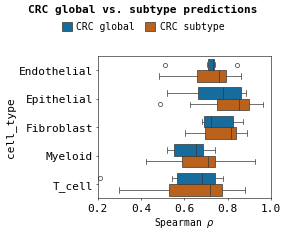

In [63]:
fig, ax = plt.subplots(figsize=(6, 5))

sns.boxplot(
    data=plot_df,
    x='spearman',
    y='cell_type',
    hue='group',
    palette={
        'CRC global': '#0072B2',
        'CRC subtype': '#D55E00'
    },
    ax=ax
)

ax.set_xlim(0.2, 1.)
ax.set_xlabel(r"Spearman $\rho$", fontsize=14)

fig.suptitle(
    "CRC global vs. subtype predictions",
    fontsize=16,
    fontweight='bold',
    y=0.95
)

# Legend on top (like before)
handles, labels = ax.get_legend_handles_labels()
fig.legend(
    handles, labels,
    loc='upper center',
    bbox_to_anchor=(0.5, 0.9),
    ncol=2,
    frameon=False,
    fontsize=14
)

ax.get_legend().remove()

plt.tight_layout(rect=[0, 0, 1, 0.88])
plt.savefig(f"{fig_save_path}/boxplot_spearman.svg", bbox_inches='tight')
plt.show()

In [64]:
def subsample_adata(adata, fraction=0.1, random_state=42):
    x = fraction

    n_cells = adata.n_obs
    n_subsample = int(n_cells * x)

    # Randomly choose cell indices
    np.random.seed(random_state)  # for reproducibility
    subsample_idx = np.random.choice(n_cells, n_subsample, replace=False)

    # Create the subsampled AnnData
    return adata[subsample_idx].copy()

In [65]:
adata.obsm['recon_x'] = model.get_normalized_expression(adata=adata, batch_size=4096, library_size=1e4)

In [66]:
# Get cellina spatial for non CRC cells
adata_list = []
select_ct = "Fibroblast"
adata_fib = results[select_ct].copy()
control_mask = adata_fib.obs[domains_key].astype(str).str.contains('REF')
X = adata_fib.obsm['recon_x'][control_mask.values, :]
X = np.log1p(X)
adata_control = ad.AnnData(X=X, 
                           obs=adata_fib.obs[control_mask])
#adata_list.append(subsample_adata(adata_control, fraction=0.1, random_state=0))
adata_list.append(subsample_adata(adata_control, fraction=1, random_state=0))

for microenv in microenvironments:
    # Get real latents for cells in this microenvironment
    real_mask = adata.obs['microenvironment'].astype(str).str.contains(microenv) & (adata.obs[labels_key].astype(str) == select_ct)
    X = adata.obsm['recon_x'][real_mask.values, :]
    X = np.log1p(X)
    obs=adata.obs[real_mask]
    adata_real = ad.AnnData(X=X, obs=obs)
    adata_real.obs['microenvironment'] = microenv
    #adata_list.append(subsample_adata(adata_real, fraction=0.2, random_state=0))
    adata_list.append(subsample_adata(adata_real, fraction=1., random_state=0))
    
    # Get counterfactual latents for this microenvironment
    X = adata_fib.uns[f'counterfactual_x_{microenv}']
    X = np.log1p(X)
    obs = adata_fib.obs[~adata_fib.obs[domains_key].str.contains('CRC')]
    obs['microenvironment'] = f"{microenv}_counterfactual"
    adata_cf = ad.AnnData(X=X, obs=obs)
    #adata_list.append(subsample_adata(adata_cf, fraction=0.1, random_state=0))
    adata_list.append(subsample_adata(adata_cf, fraction=1., random_state=0))

/tmp/ipykernel_3849743/1424085326.py:28: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  obs['microenvironment'] = f"{microenv}_counterfactual"
/tmp/ipykernel_3849743/1424085326.py:28: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  obs['microenvironment'] = f"{microenv}_counterfactual"
/tmp/ipykernel_3849743/1424085326.py:28: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: 

In [67]:
# Merge all adatas in list
adata_fib_merged = ad.concat(adata_list, join='outer')
adata_fib_merged.obs_names_make_unique()

/data/ddimitrov/software/miniforge3/envs/cellina/lib/python3.10/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [68]:
sc.pp.pca(adata_fib_merged, n_comps=50)
sc.pp.neighbors(adata_fib_merged, n_pcs=50)
sc.tl.umap(adata_fib_merged)

In [69]:
# rename REF, TVA to control
#adata_fib_merged.obs['microenvironment'] = adata_fib_merged.obs['microenvironment'].replace({'REF': 'Control', 'TVA': 'Control'})
adata_fib_merged.obs['domain'] = adata_fib_merged.obs['microenvironment']
adata_fib_merged.obs['domain'] = adata_fib_merged.obs['domain'].replace({'210_REF': 'Control'})
adata_fib_merged.obs['domain'] = adata_fib_merged.obs['domain'].astype('category')

In [70]:
palette = {
    # Control
    'Control': '#E69F00',  # orange

    # Immune hot - CRC2 (vermillion)
    'CRC2': "#580803",
    'CRC2_counterfactual': '#F4A582',  # lighter version

    # Immune cold - CRC4 (blue)
    'CRC4': "#011080",
    'CRC4_counterfactual': '#92C5DE',  # lighter version
}

In [71]:
adata_fib_merged.obs['domain'].value_counts()

domain
CRC1                   28955
CRC1_counterfactual     7006
CRC2_counterfactual     7006
CRC4_counterfactual     7006
CRC3_counterfactual     7006
CRC4                    6272
CRC3                    3566
CRC2                    2736
Control                 2456
Name: count, dtype: int64

... storing 'cell_id' as categorical
... storing 'cell' as categorical
... storing 'microenvironment' as categorical


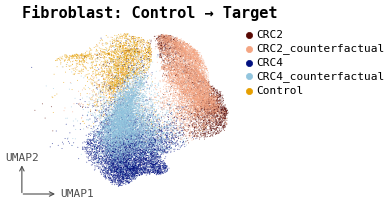

In [72]:
import matplotlib.pyplot as plt

domains = ['Control', 'CRC2', 'CRC2_counterfactual', 'CRC4', 'CRC4_counterfactual']
adata_sub = adata_fib_merged[adata_fib_merged.obs['domain'].isin(domains)].copy()

ax = sc.pl.umap(
    adata_sub,
    color='domain',
    palette=palette,
    show=False,
    title='',
    size=8,
    alpha=0.7,
    frameon=False,
)

fig = ax.figure
fig.set_size_inches(6, 4)
ax.set_position([0.05, 0.08, 0.72, 0.84])

ax.set_title(
    f"{select_ct}: Control → Target",
    fontsize=22,
    fontweight='bold',
    pad=12,
    loc='left',
)

ax.set_xlabel('')
ax.set_ylabel('')
ax.set_xticks([])
ax.set_yticks([])

arrow_kw = dict(arrowstyle='->', color='0.3', lw=1.6)
x0, y0 = ax.get_xlim()[0], ax.get_ylim()[0]
offset = (ax.get_xlim()[1] - x0) * 0.08
ax.annotate('', xy=(x0 + offset * 2, y0), xytext=(x0, y0),
            arrowprops=arrow_kw, annotation_clip=False)
ax.annotate('', xy=(x0, y0 + offset * 2), xytext=(x0, y0),
            arrowprops=arrow_kw, annotation_clip=False)
ax.text(x0 + offset * 2.2, y0, 'UMAP1', fontsize=16, color='0.3', va='center')
ax.text(x0, y0 + offset * 2.2, 'UMAP2', fontsize=16, color='0.3', ha='center')

legend = ax.get_legend()
if legend is not None:
    legend.set_title('')
    legend.get_frame().set_linewidth(0)
    legend.get_frame().set_alpha(0)
    for text in legend.get_texts():
        text.set_fontsize(16)
    for handle in legend.legend_handles:
        handle.set_sizes([80])
    legend.set_bbox_to_anchor((1.02, 1))
    legend.set_loc('upper left')

for coll in ax.collections:
    coll.set_rasterized(True)

plt.show()

fig.savefig(
    f"{fig_save_path}/{slide_id}_umap_cf_Fibroblasts.svg",
    dpi=300,
    bbox_inches='tight',
    transparent=True,
)

### Pathways

In [73]:
from plotting import plot_pathway_activity

In [74]:
# Get module x gene matrix
gene_modules = hs.modules
gene_c = hs.results[['C']]
df = gene_c.join(gene_modules.rename("Module"))
module_gene_matrix = df.pivot_table(index="Module", columns=df.index, values="C", fill_value=0)

In [75]:
pw_progeny = dc.op.progeny(organism="human")
pw_hallmark = dc.op.hallmark(organism="human")

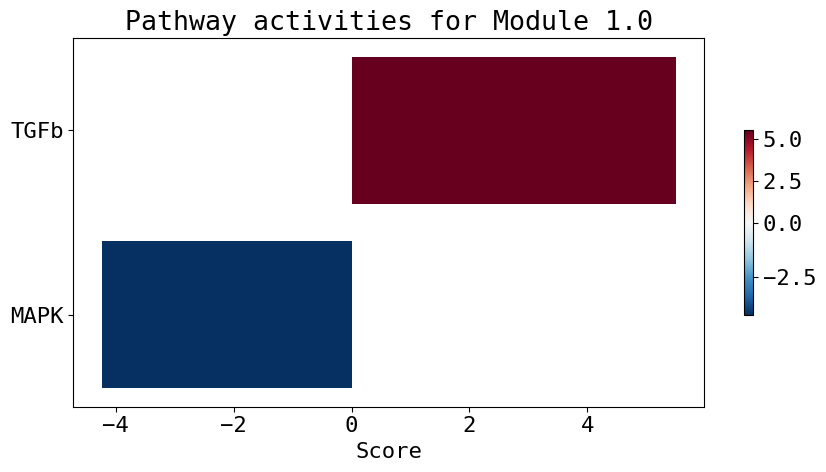

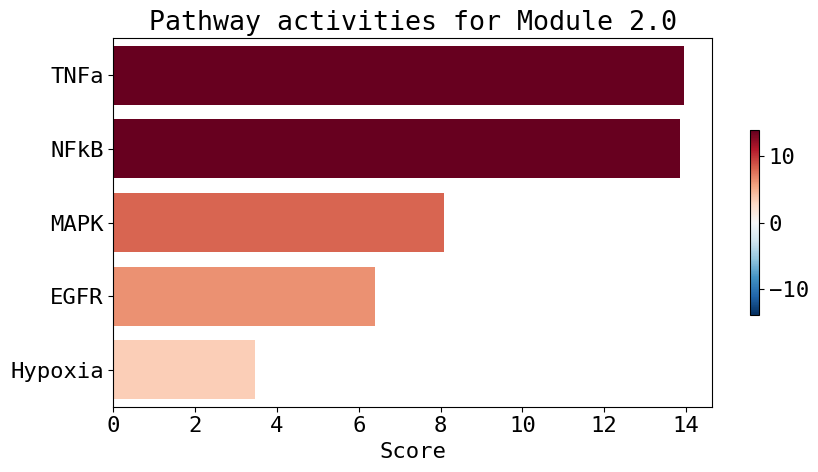

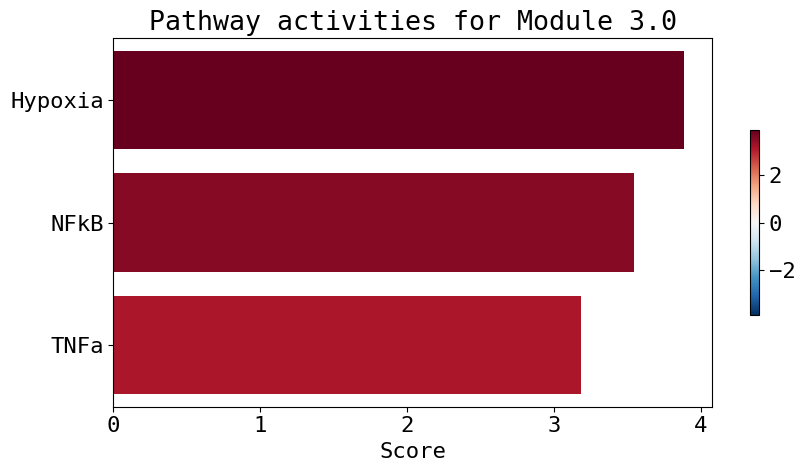

In [76]:
# Progeny pathway activity
pw_acts, pw_padj = dc.mt.ulm(data=module_gene_matrix, net=pw_progeny)
plot_pathway_activity(pw_acts, pw_padj, alpha=0.05)

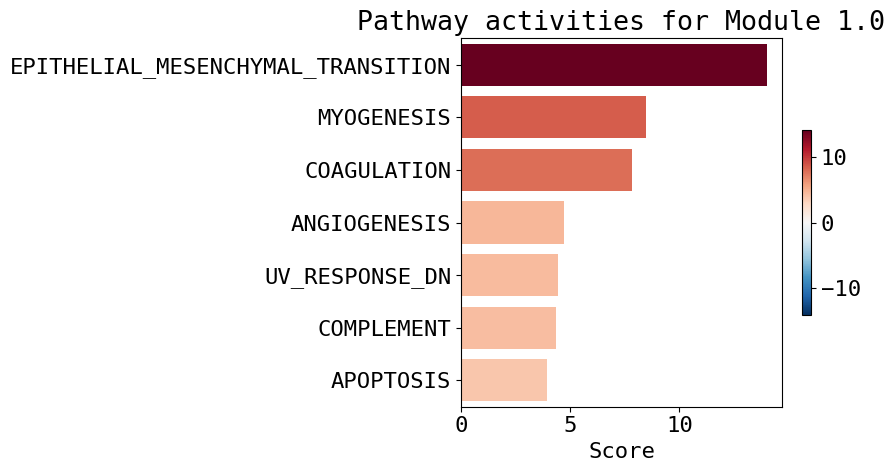

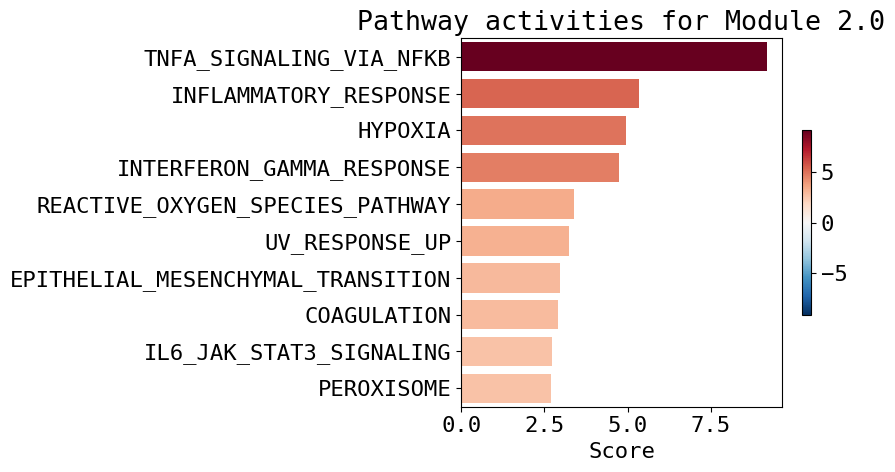

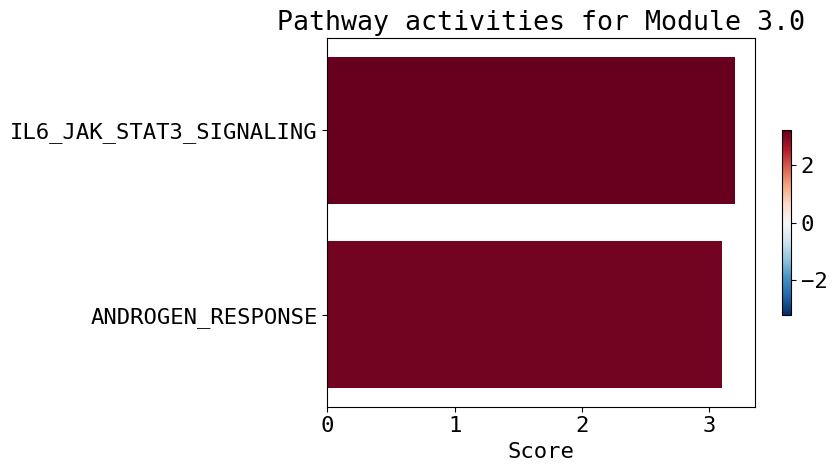

In [77]:
# Hallmark pathway activity
pw_acts, pw_padj = dc.mt.ulm(data=module_gene_matrix, net=pw_hallmark)
plot_pathway_activity(pw_acts, pw_padj, alpha=0.05)

### Pathway targets

In [78]:
sc.pp.log1p(adata_crc)
sc.tl.rank_genes_groups(adata_crc, groupby="top_module")

In [79]:
deg_1 = sc.get.rank_genes_groups_df(adata_crc, group="1").set_index("names")

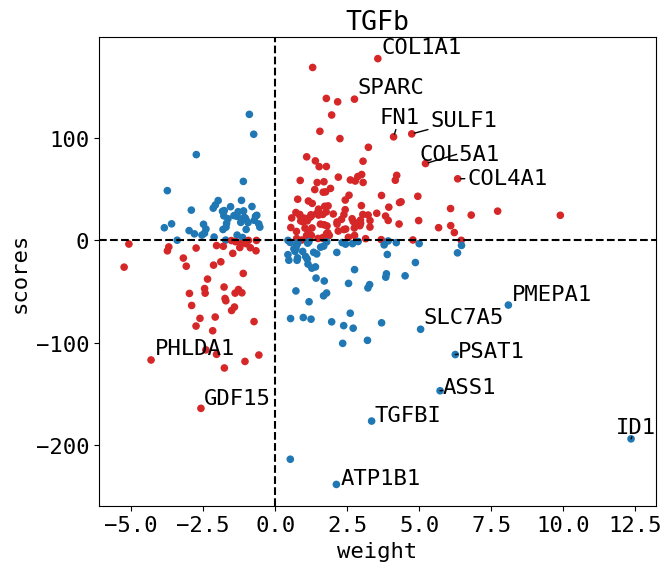

In [80]:
dc.pl.source_targets(data=deg_1, x="weight", y="scores", net=pw_progeny, name="TGFb", top=15, figsize=(7, 6))

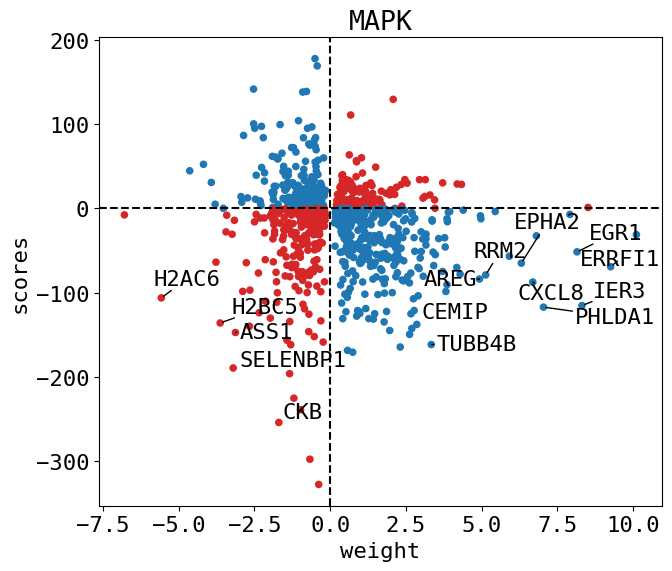

In [81]:
dc.pl.source_targets(data=deg_1, x="weight", y="scores", net=pw_progeny, name="MAPK", top=15, figsize=(7, 6))

In [82]:
deg_2 = sc.get.rank_genes_groups_df(adata_crc, group="2").set_index("names")

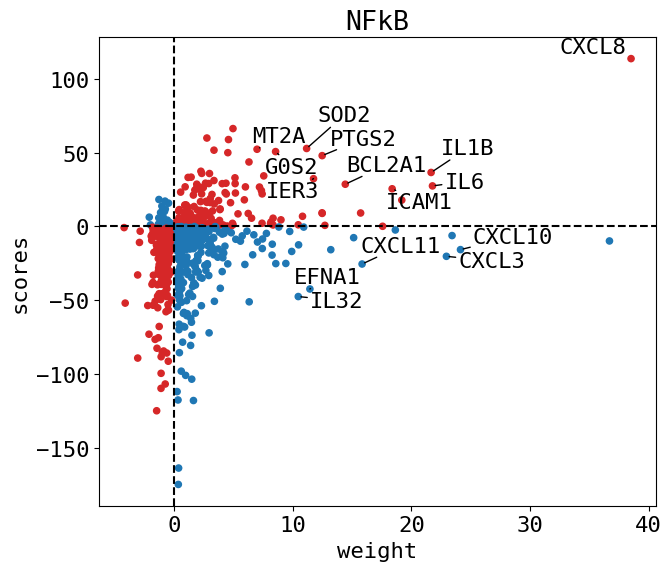

In [83]:
dc.pl.source_targets(data=deg_2, x="weight", y="scores", net=pw_progeny, name="NFkB", top=15, figsize=(7, 6))

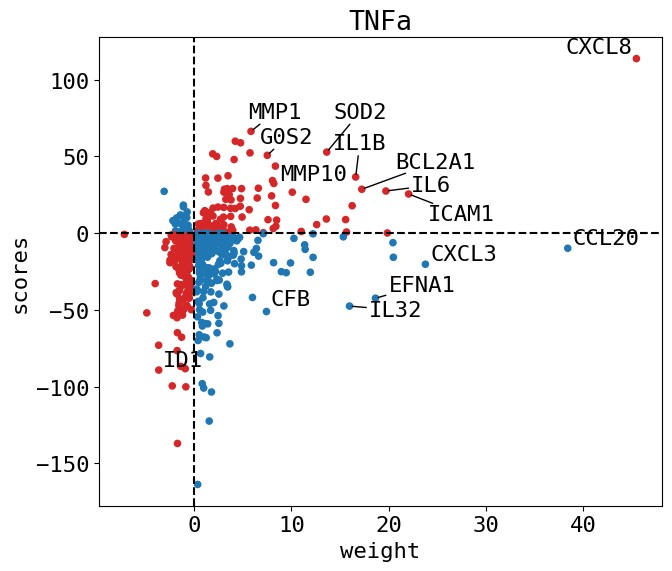

In [84]:
dc.pl.source_targets(data=deg_2, x="weight", y="scores", net=pw_progeny, name="TNFa", top=15, figsize=(7, 6))

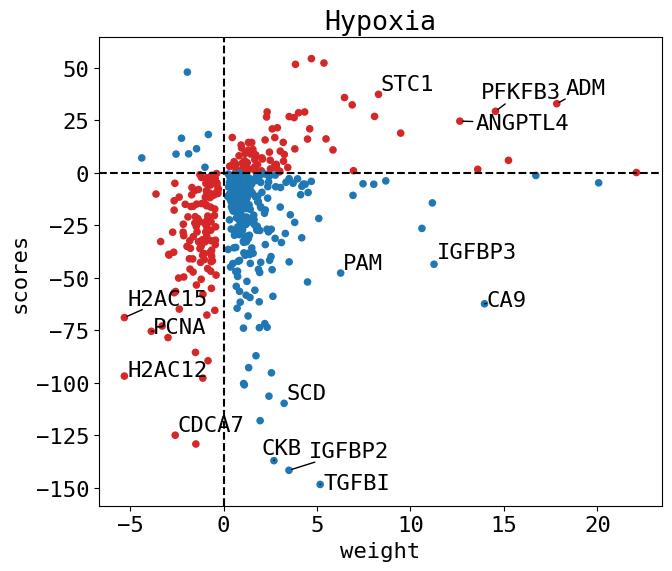

In [85]:
dc.pl.source_targets(data=deg_2, x="weight", y="scores", net=pw_progeny, name="Hypoxia", top=15, figsize=(7, 6))

# Pathway-based perturbations

In [86]:
is_celltype = "Fibroblast"

def compute_microenv_logfc(adata, domains_key, labels_key, ref_label, crc_label):
    """Compute global and cell-type-specific logFC between a CRC microenvironment and reference."""
    # Global: all cells pooled together
    pdata_global = dc.pp.pseudobulk(
        adata=adata, sample_col=domains_key, groups_col=None, mode='sum', layer='counts'
    )
    sc.pp.normalize_total(pdata_global, target_sum=1e4)
    sc.pp.log1p(pdata_global)

    global_logfc_series = pd.Series(
        (pdata_global[pdata_global.obs[domains_key] == crc_label].X
         - pdata_global[pdata_global.obs[domains_key] == ref_label].X).flatten(),
        index=pdata_global.var_names,
    )

    # Cell-type-specific
    pdata_ct = dc.pp.pseudobulk(
        adata=adata, sample_col=domains_key, groups_col=labels_key, mode='sum', layer='counts'
    )
    sc.pp.normalize_total(pdata_ct, target_sum=1e4)
    sc.pp.log1p(pdata_ct)

    cell_types_with_both = [
        ct for ct in pdata_ct.obs[labels_key].unique()
        if ((pdata_ct.obs[domains_key] == ref_label) & (pdata_ct.obs[labels_key] == ct)).any()
        and ((pdata_ct.obs[domains_key] == crc_label) & (pdata_ct.obs[labels_key] == ct)).any()
    ]

    domain_logfc_df = pd.concat(
        [
            pd.Series(
                (pdata_ct[(pdata_ct.obs[domains_key] == crc_label) & (pdata_ct.obs[labels_key] == ct)].X
                 - pdata_ct[(pdata_ct.obs[domains_key] == ref_label) & (pdata_ct.obs[labels_key] == ct)].X
                ).flatten(),
                index=pdata_ct.var_names,
                name=ct,
            )
            for ct in cell_types_with_both
        ],
        axis=1,
    ).T

    print(f"Global logFC: {global_logfc_series.shape[0]} genes")
    print(f"Cell-type logFC: {domain_logfc_df.shape[0]} cell types x {domain_logfc_df.shape[1]} genes")
    return global_logfc_series, domain_logfc_df

In [87]:
adata_pert = results[is_celltype].copy()

In [88]:
# rename REF, TVA to control
adata_pert.obs['domain'] = adata_pert.obs['microenvironment']
adata_pert.obs['domain'] = adata_pert.obs['domain'].replace({'210_REF': 'Control'})
adata_pert.obs['domain'] = adata_pert.obs['domain'].astype('category')

/tmp/ipykernel_3849743/3980123342.py:3: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  adata_pert.obs['domain'] = adata_pert.obs['domain'].replace({'210_REF': 'Control'})


In [89]:
adata_pert.obs.domain.value_counts()

domain
CRC1       28955
CRC4        6272
210_TVA     4550
CRC3        3566
CRC2        2736
Control     2456
Name: count, dtype: int64

In [90]:
adata_pert.X = adata_pert.layers['counts'].copy()
sc.pp.normalize_total(adata_pert, target_sum=1e4)
sc.pp.log1p(adata_pert)

1. Find DE(Ref, CRC1) and DE(Ref, CRC2)

In [91]:
select_groups = ['CRC1', 'CRC2']
adata_pert = adata_pert[adata_pert.obs['domain'].isin(['Control'] + select_groups)].copy()

# DE analysis on single cell type (for identifying significant genes for pathway intersection)
sc.tl.rank_genes_groups(
    adata_pert,
    groupby='domain',
    groups=select_groups,
    reference='Control',
    method='wilcoxon'
)

a_raw = sc.get.rank_genes_groups_df(adata_pert, group=select_groups[0])
b_raw = sc.get.rank_genes_groups_df(adata_pert, group=select_groups[1])

# Pseudobulk logFC for ALL cell types (used for perturbation vectors)
global_logfc_a, ct_logfc_df_a = compute_microenv_logfc(
    adata, domains_key='microenvironment', labels_key=labels_key,
    ref_label='210_REF', crc_label='CRC1'
)
global_logfc_b, ct_logfc_df_b = compute_microenv_logfc(
    adata, domains_key='microenvironment', labels_key=labels_key,
    ref_label='210_REF', crc_label='CRC2'
)

Global logFC: 2000 genes
Cell-type logFC: 9 cell types x 2000 genes
Global logFC: 2000 genes
Cell-type logFC: 9 cell types x 2000 genes


In [92]:
a = a_raw[(a_raw['pvals_adj'] < 0.05) & (abs(a_raw['logfoldchanges']) > 1)]
b = b_raw[(b_raw['pvals_adj'] < 0.05) & (abs(b_raw['logfoldchanges']) > 1)]

In [93]:
a

,names,scores,logfoldchanges,pvals,pvals_adj
0,COL1A1,45.708591,4.127557,0.000000e+00,0.000000e+00
1,COL1A2,39.792480,4.230020,0.000000e+00,0.000000e+00
2,SPARC,39.247776,4.419678,0.000000e+00,0.000000e+00
3,COL3A1,34.953167,3.267604,1.159111e-267,5.795554e-265
4,MMP2,33.023300,3.652195,3.761138e-239,1.504455e-236
...,...,...,...,...,...
1995,SCARA5,-3.531029,-2.320505,4.139457e-04,3.712517e-03
1996,ADAM28,-5.678895,-2.692927,1.355682e-08,2.101832e-07
1997,JCHAIN,-7.422693,-2.852822,1.147627e-13,2.441759e-12
1998,IGKC,-8.458501,-1.489881,2.708371e-17,6.687335e-16


In [94]:
b

,names,scores,logfoldchanges,pvals,pvals_adj
0,SOD2,22.986431,4.499898,6.371841e-117,1.274368e-113
1,C11orf96,22.724030,4.691693,2.592982e-114,2.592982e-111
2,MMP1,18.607372,5.824482,2.800146e-77,1.866764e-74
3,COL4A1,18.231499,3.545161,2.902523e-74,1.451261e-71
4,MT2A,17.871536,3.184686,1.965042e-71,7.860170e-69
...,...,...,...,...,...
1995,HLA-DRB1,-6.943171,-2.230428,3.833961e-12,2.072411e-10
1996,FBLN1,-7.051506,-2.382657,1.769915e-12,9.832863e-11
1997,IGKC,-9.653533,-2.463055,4.749077e-22,4.522930e-20
1998,COL3A1,-13.167659,-1.673463,1.347106e-39,1.924437e-37


2. Find pathway-defining genes

In [95]:
pathway = "TGFb"
weight_threshold = 1
c = pw_progeny[(pw_progeny.source==pathway) & (pw_progeny.weight>weight_threshold)]

In [96]:
pathway = "NFkB"
weight_threshold = 1
d = pw_progeny[(pw_progeny.source==pathway) & (pw_progeny.weight>weight_threshold)]

3. Find intersection of DE genes and pathway genes

In [97]:
P = set(a.names).intersection(set(c.target))
#Q = set(b.names).intersection(set(c.target))

In [98]:
#P = set(a.names).intersection(set(d.target))
Q = set(b.names).intersection(set(d.target))

In [99]:
len(P), len(Q)

(65, 49)

4. Generate counterfactual populations for each target gene set

In [100]:
# logFC vectors for ALL cell types, restricted to pathway P genes
logfc_set_a = {ct: ct_logfc_df_a.loc[ct].reindex(list(P)).fillna(0) for ct in ct_logfc_df_a.index}
print(f"logfc_set_a: {len(logfc_set_a)} cell types, {len(P)} pathway genes each")

logfc_set_a: 9 cell types, 65 pathway genes each


In [101]:
adata.X = adata.layers['counts'].copy()
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

In [102]:
from cellina._spatial_utils import make_neighbor_perturbation

make_neighbor_perturbation(
    adata,
    perturbations=logfc_set_a,
    groupby=labels_key,
    obsm_key_out='spatial_x_cf',
    base=np.e,
)

In [103]:
adata.X = adata.layers['counts'].copy()

In [104]:
is_tumor_region = adata.obs[domains_key].astype(str).str.contains('CRC', regex=True)
mask_control = ~is_tumor_region & (adata.obs[labels_key]==is_celltype)
idx_control = np.where(mask_control.values)[0]

In [105]:
adata_pert.uns['pert_P'] = model.get_perturbed_expression(
    adata,
    indices=idx_control,
    batch_size=4096,
    spatial_obsm_key="spatial_x_cf",
    library_size=1e4)

In [106]:
# logFC vectors for ALL cell types, restricted to pathway Q genes
logfc_set_b = {ct: ct_logfc_df_b.loc[ct].reindex(list(Q)).fillna(0) for ct in ct_logfc_df_b.index}
print(f"logfc_set_b: {len(logfc_set_b)} cell types, {len(Q)} pathway genes each")

logfc_set_b: 9 cell types, 49 pathway genes each


In [107]:
from cellina._spatial_utils import make_neighbor_perturbation

make_neighbor_perturbation(
    adata,
    perturbations=logfc_set_b,
    groupby=labels_key,
    obsm_key_out='spatial_x_cf',
    base=np.e,
)

In [108]:
adata_pert.uns['pert_Q'] = model.get_perturbed_expression(
    adata,
    indices=idx_control,
    batch_size=4096,
    spatial_obsm_key="spatial_x_cf",
    library_size=1e4)

In [109]:
adata_pert.obs.domain.value_counts()

domain
CRC1       28955
CRC2        2736
Control     2456
Name: count, dtype: int64

5. Correlation with observed microenv sets CRC1 (pert_P) and CRC2 (pert_Q)

In [110]:
mask_control = ~adata_pert.obs['domain'].str.contains('CRC')
control = adata_pert.layers['counts'].todense()[mask_control]
control = np.asarray(control)

In [111]:
is_in_microenv = adata_pert.obs['domain'].str.contains('CRC1')
mask_target = is_in_microenv
target = adata_pert.layers['counts'].todense()[mask_target]
target = np.asarray(target)

counterfactual_p = adata_pert.uns['pert_P']

In [112]:
pear_p, spear_p = compute_correlations(control, target, counterfactual_p, deg=deg)
pear_p, spear_p

(0.9307545853799364, 0.6995394884872123)

In [113]:
is_in_microenv = adata_pert.obs['domain'].str.contains('CRC2')
mask_target = is_in_microenv
target = adata_pert.layers['counts'].todense()[mask_target]
target = np.asarray(target)

counterfactual_q = adata_pert.uns['pert_Q']

In [114]:
pear_q, spear_q = compute_correlations(control, target, counterfactual_q, deg=deg)
pear_q, spear_q

(0.8264871911584273, 0.7435955898897474)

In [115]:
pert_results = {'CRC1-perturbed': {'pearson': pear_p, 'spearman': spear_p},
                'CRC2-perturbed': {'pearson': pear_q, 'spearman': spear_q}}

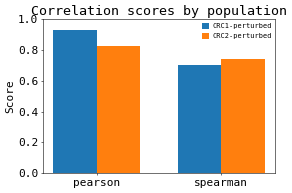

In [116]:
populations = list(pert_results.keys())
metrics = ['pearson', 'spearman']

x = np.arange(len(metrics))  # [0, 1]
width = 0.35

plt.figure(figsize=(6,4))

for i, pop in enumerate(populations):
    values = [pert_results[pop][m] for m in metrics]
    plt.bar(x + i * width, values, width, label=pop)

plt.xticks(x + width / 2, metrics)
plt.ylim(0, 1)
plt.ylabel("Score")
plt.title("Correlation scores by population")
plt.legend()
plt.show()

In [117]:
def get_lfc_vector(control, counterfactual, normalize_counts=True, deg=200):
    if normalize_counts:
        control = _normalize_counts(control)
        counterfactual = _normalize_counts(counterfactual)

    mean_control = np.nanmean(control, axis=0)
    mean_cf = np.nanmean(counterfactual, axis=0)
    

    # compute log2 fold changes
    lfc = safe_log2_fold_change(mean_cf, mean_control)
    deg_scores = np.abs(lfc)
    top_features = np.argsort(-deg_scores)[:deg]

    return lfc, top_features

In [118]:
lfc_results = []
deg_results = []
for subtype, cf_group in zip(select_groups, ['pert_P', 'pert_Q']):
    print(subtype, cf_group)
    counterfactual = adata_pert.uns[cf_group]
    lfc, top_features = get_lfc_vector(control, counterfactual, normalize_counts=True, deg=50)
    lfc_results.append(lfc)
    deg_results.append(top_features)

CRC1 pert_P
CRC2 pert_Q


In [119]:
len(set(deg_results[0]).intersection(set(deg_results[1])))

34

In [120]:
lfc_map = a_raw.set_index('names')['logfoldchanges']

sorted_lfc_a = lfc_map.reindex(adata.var_names).values

In [121]:
lfc_map = b_raw.set_index('names')['logfoldchanges']

sorted_lfc_b = lfc_map.reindex(adata.var_names).values

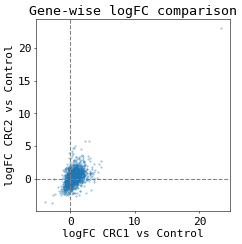

In [122]:
#lfc_A, lfc_B = lfc_results  # unpack
lfc_A, lfc_B = sorted_lfc_a, sorted_lfc_b

plt.figure(figsize=(5,5))
plt.scatter(lfc_A, lfc_B, alpha=0.3, s=5)
plt.axhline(0, color='grey', linestyle='--')
plt.axvline(0, color='grey', linestyle='--')
plt.xlabel("logFC CRC1 vs Control")
plt.ylabel("logFC CRC2 vs Control")
plt.title("Gene-wise logFC comparison")
plt.show()

In [123]:
# Concat counterfactuals and put them in a temp adata
recon_control = adata.obsm['recon_x'][idx_control]
counterfactual_concat = np.concatenate([recon_control,
                                        counterfactual_p, 
                                        counterfactual_q], axis=0)

obs_control = adata.obs.iloc[idx_control].copy()
obs_control['domain'] = 'Control'
obs_p = adata.obs.iloc[idx_control].copy()
obs_p['domain'] = 'CRC1_perturbed'
obs_q = adata.obs.iloc[idx_control].copy()
obs_q['domain'] = 'CRC2_perturbed'

obs_concat = pd.concat([obs_control, obs_p, obs_q], ignore_index=True)

adata_cf_concat = ad.AnnData(X=counterfactual_concat, obs=obs_concat)

/data/ddimitrov/software/miniforge3/envs/cellina/lib/python3.10/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


In [124]:
sc.pp.normalize_total(adata_cf_concat, target_sum=1e4)
sc.pp.log1p(adata_cf_concat)
sc.pp.pca(adata_cf_concat, n_comps=50)
sc.pp.neighbors(adata_cf_concat, n_pcs=50)
sc.tl.umap(adata_cf_concat)

... storing 'cell_id' as categorical
... storing 'cell' as categorical
... storing 'domain' as categorical


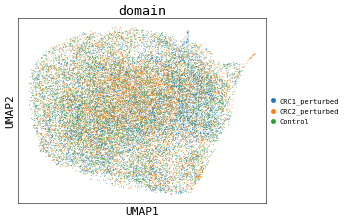

In [125]:
sc.pl.umap(adata_cf_concat, color='domain')